In [38]:
# TODO 1: pull SPY only (2010-01-01 for more regimes, or reuse 2020)
# TODO 2: ma50 = 50-day mean of Close; ma200 = 200-day mean
# TODO 3: signal = 1 when ma50 > ma200, else 0
# TODO 4: position = signal shifted 1 day
# TODO 5: strat_ret = position * ret
# TODO 6: equity curves for strategy and buy-and-hold  -> (1+r).cumprod()
# TODO 7: plot both on one chart
# TODO 8: count trades -> position.diff().abs().sum() / 2
# TODO 9: net returns after 5bp per trade
# TODO 10: comparison table: total ret, ann ret, ann vol, Sharpe, MaxDD, trades, time in market
# TODO 11: findings -- did it beat buy-and-hold, and on which metric

%load_ext autoreload
%autoreload 2

import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

from src import metrics

df = yf.download("SPY", start="2010-01-01", multi_level_index=False, auto_adjust=True)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[*********************100%***********************]  1 of 1 completed


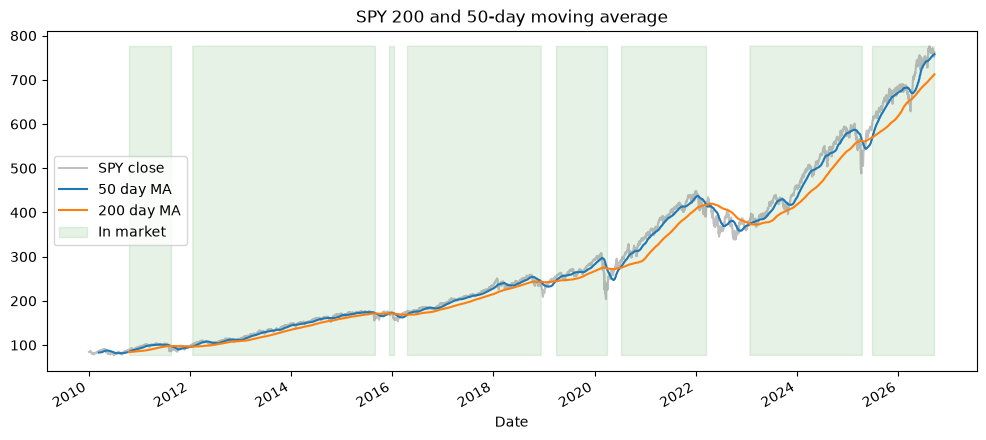

In [39]:
close = df["Close"]
df["ret"] = metrics.daily_returns(prices=close)


df["ma50"] = close.rolling(50).mean()
df["ma200"] = close.rolling(200).mean()

plt.figure(figsize=(12, 5))
close.plot(label="SPY close", alpha=0.5, color="gray")
df["ma50"].plot(label="50 day MA")
df["ma200"].plot(label="200 day MA")
plt.title("SPY 200 and 50-day moving average")


plt.fill_between(
    close.index,
    close.min(),
    close.max(),
    where=(df["ma50"] > df["ma200"]),
    alpha=0.1,
    color="green",
    label="In market",
)

plt.legend()
plt.savefig("../images/p3_MA_200_50graph.png")
plt.show()


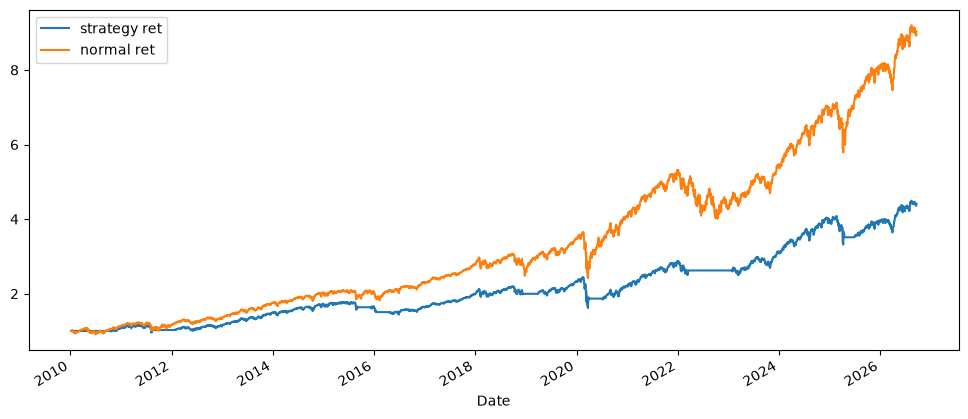

In [40]:
df["signal"] = (df["ma50"] > df["ma200"]).astype(int)
df["position"] = df["signal"].shift(1)
df["strategy"] = df["ret"] * df["position"]

bt = df[["ret", "strategy", "position"]].dropna()

equity_strat = (1 + bt["strategy"]).cumprod()
equity_ret = (1 + bt["ret"]).cumprod()

plt.figure(figsize=(12, 5))
equity_strat.plot(label="strategy ret")
equity_ret.plot(label="normal ret")


plt.legend()
plt.savefig("../images/p3_returns_50-200.png")
plt.show()


In [41]:
trades = bt["position"].diff().abs().fillna(0)
n_trades = trades.sum() / 2

cost = 0.0005
bt["strategy_net"] = bt["strategy"] - trades * cost

print(f"{n_trades:.0f} round-trip trades")
print(f"Time in market: {bt['position'].mean():.1%}")


8 round-trip trades
Time in market: 80.0%


In [42]:
table = pd.DataFrame(
    {
        "Buy & hold": metrics.stats(bt["ret"]),
        "Strategy (gross)": metrics.stats(bt["strategy"]),
        "Strategy (net)": metrics.stats(bt["strategy_net"]),
    }
).T

print(table.to_markdown())

|                  |   Total ret |   Ann. ret |   Ann. Vol |   Sharpe |     MaxDD |
|:-----------------|------------:|-----------:|-----------:|---------:|----------:|
| Buy & hold       |     8.02808 |  0.14106   |   0.170587 | 0.859248 | -0.337173 |
| Strategy (gross) |     3.41104 |  0.0930853 |   0.13949  | 0.708182 | -0.337173 |
| Strategy (net)   |     3.37802 |  0.0925928 |   0.139498 | 0.704919 | -0.337173 |
